# Milos — farmer WSP + replan Gantt

Self-contained under `milos/` (no `agent/`). Primary plots are **farmer-only** (5 tiles).

Optional: smoke `[wsp_plan]` lines from the live agent are filtered to zone I (`t1`–`t5`) so you can compare day-0 / replan for the farmer snake only — not full TwoLand.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "main.py").exists() and not (ROOT / "milos").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline

from milos import (
    FARMER_TILES,
    board_for_plot,
    build_day0,
    empty_board,
    merge_wsp_plan,
)
from milos.wsp import load_wsp_plans, plot_plan, plot_zone_ops_replans
from milos.wsp.plan_actions import plot_planner_board_actions

SMOKE_LOG = ROOT / "scripts/smoke.txt"
print(SMOKE_LOG, SMOKE_LOG.exists())


/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/smoke.txt True


## Farmer-only WSP (`milos.planner.build_day0`)

Day-0 calls `milos.wsp.farmer.solve`, then planner writes an **absolute** tile board for Gantt.


[milos/wsp] farmer prestart zone I tiles=[0, 1, 2, 3, 4] from prestart.json (full=25) complete=True
complete True tiles [0, 1, 2, 3, 4]


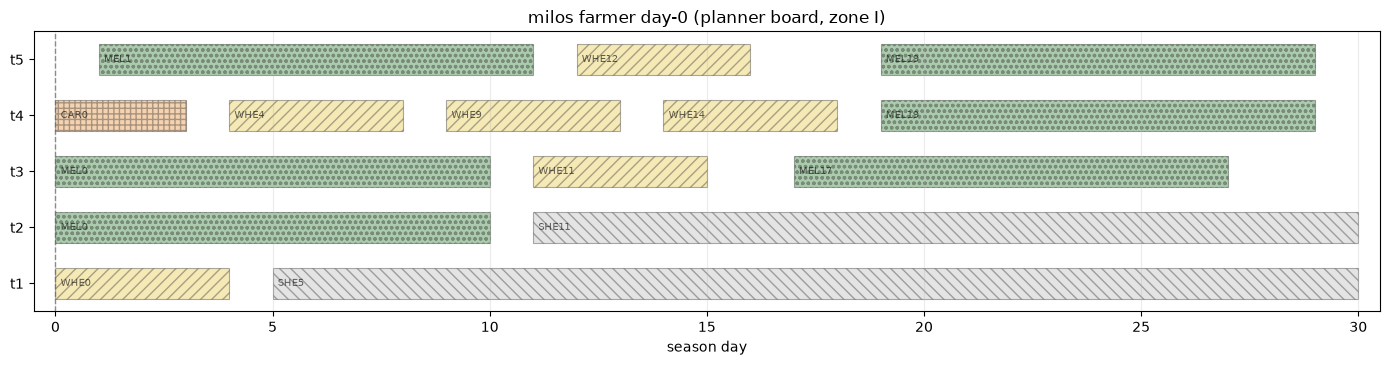

In [3]:
board, result = build_day0(starting_money=3000)
print("complete", result.complete, "tiles", sorted(board))
plot_plan(
    board_for_plot(board),
    replan_day=0,
    horizon=30,
    absolute=True,
    title="milos farmer day-0 (planner board, zone I)",
)


## Smoke log — full farmer Gantt per replan

Merge each `[wsp_plan]` via `milos.planner.merge_wsp_plan`, then plot the **full** zone-I board: past α=0.3, unchanged future α=0.6, **this replan's tiles α=1.0**.


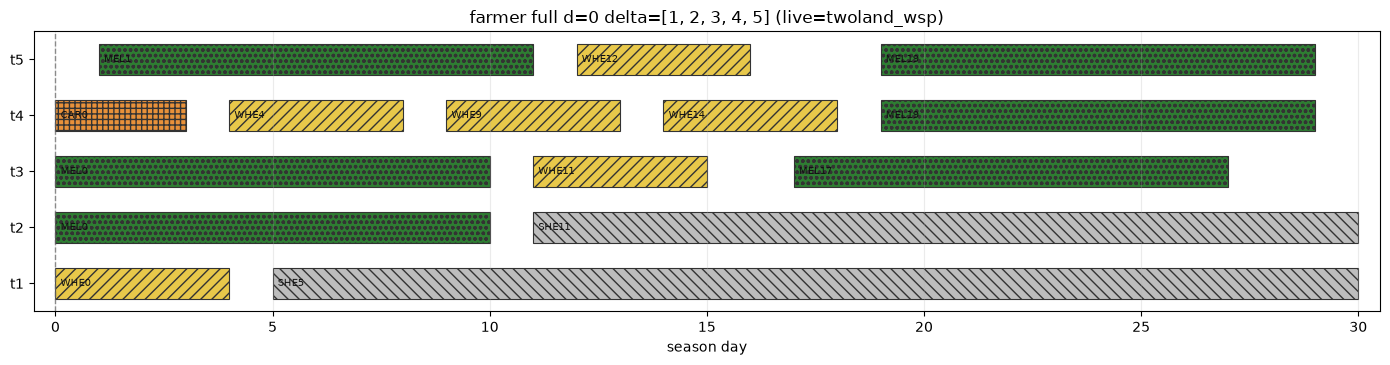

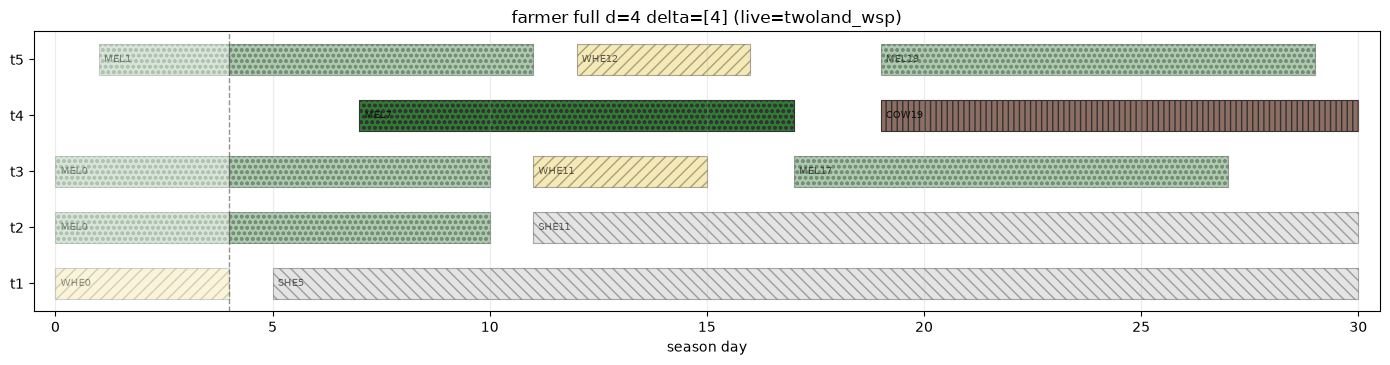

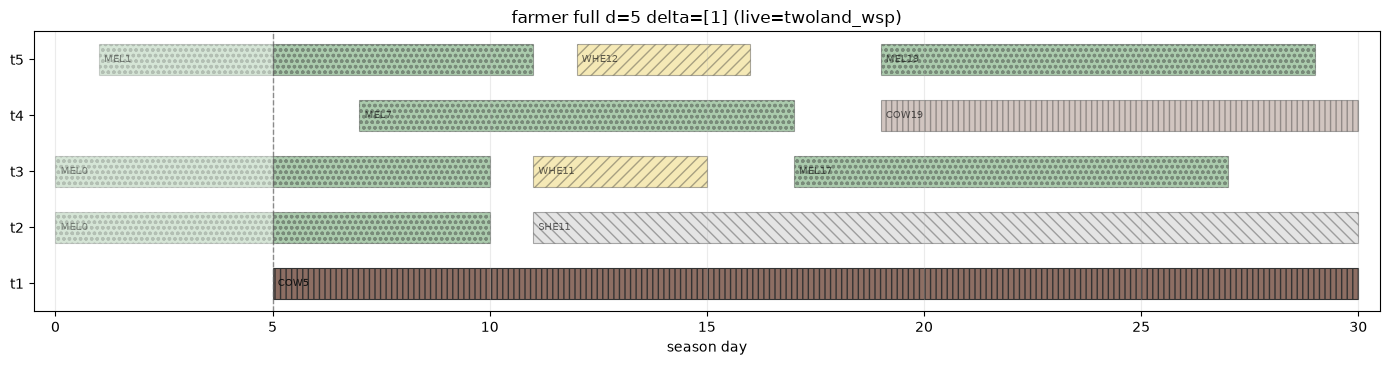

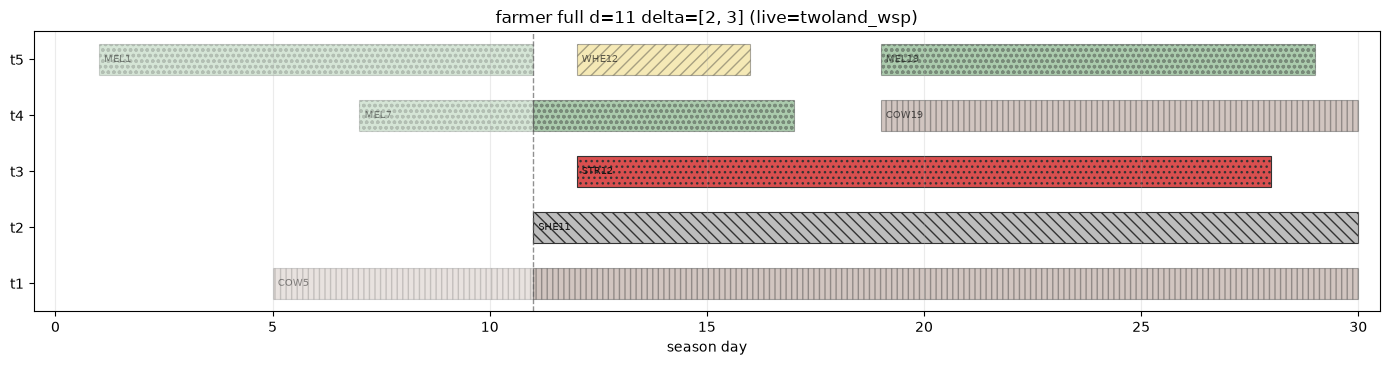

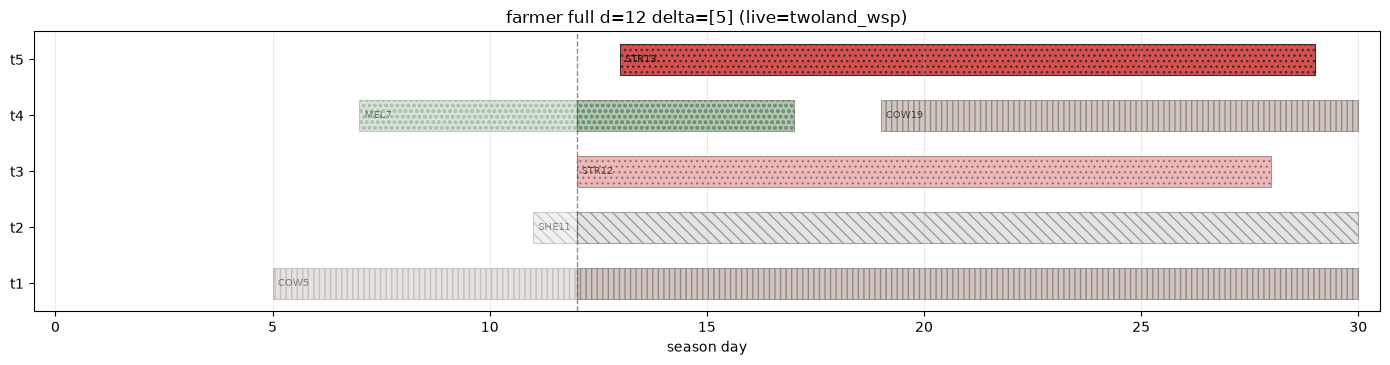

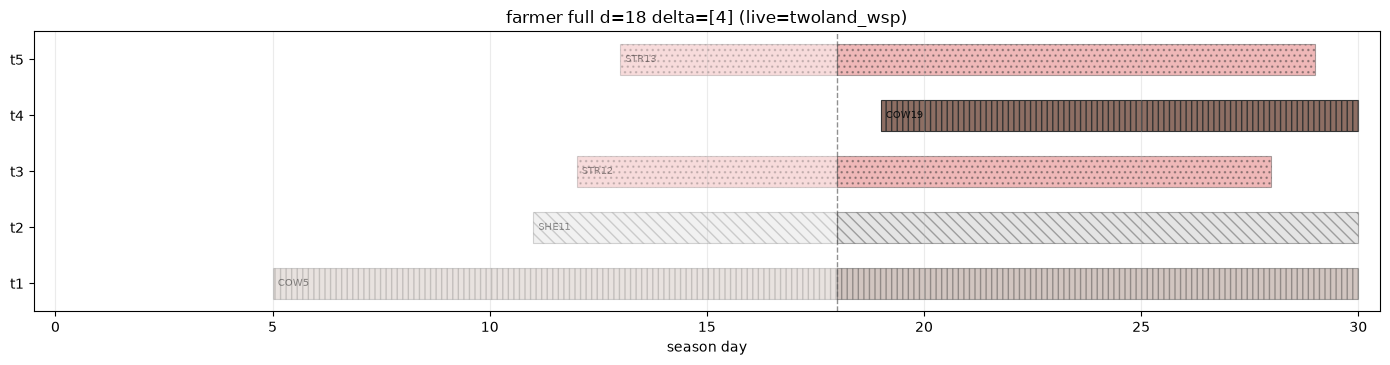

plotted 6/23 events (skipped empty farmer deltas)


In [4]:
farmer_set = set(FARMER_TILES)
plans = load_wsp_plans(SMOKE_LOG) if SMOKE_LOG.exists() else []
board = empty_board()
plotted = 0
for plan in plans:
    delta = merge_wsp_plan(board, plan, tiles=farmer_set)
    if not delta:
        continue
    plotted += 1
    plot_plan(
        board_for_plot(board),
        replan_day=plan.day,
        horizon=plan.horizon,
        now=plan.day,
        absolute=True,
        delta_tiles=delta,
        title=f"farmer full d={plan.day} delta={sorted(t+1 for t in delta)} (live={plan.solver})",
    )
print(f"plotted {plotted}/{len(plans)} events (skipped empty farmer deltas)")


## Farmer OPS by replan

Same smoke `[wsp_plan]` stream as the Gantt (live **TwoLand** agent), but **farmer / zone I only** (`t1`–`t5`). One **line + dots** per replan: total planned `daily_tile_ops` from that replan day to season end. Color = replan index (`turbo`; colorbar = replan day).


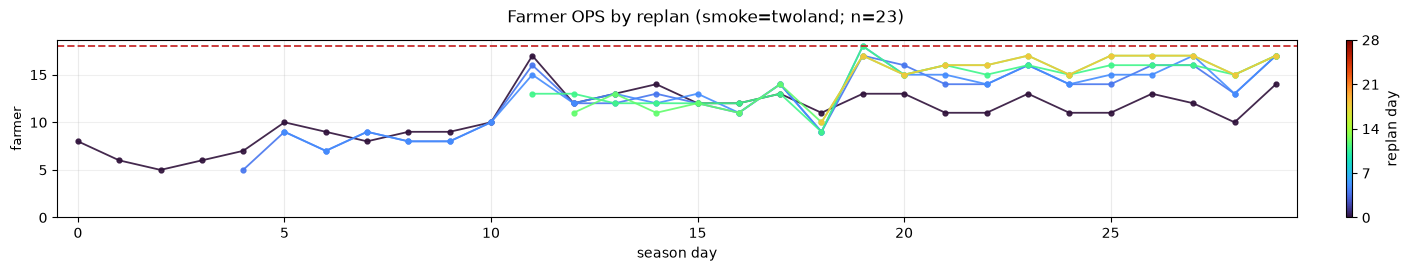

In [5]:
farmer_set = set(FARMER_TILES)
plans_farmer = load_wsp_plans(SMOKE_LOG) if SMOKE_LOG.exists() else []
plot_zone_ops_replans(
    plans_farmer,
    {"farmer": farmer_set},
    title=f"Farmer OPS by replan (smoke=twoland; n={len(plans_farmer)})",
)

## Farmer planned actions by replan

Same merged planner board as the Gantt section, shown as a **worker×action heatmap** (like `smoke_analysis.plot_worker_actions`): rollout tape stamped on the farmer snake, one figure per replan with a farmer delta.


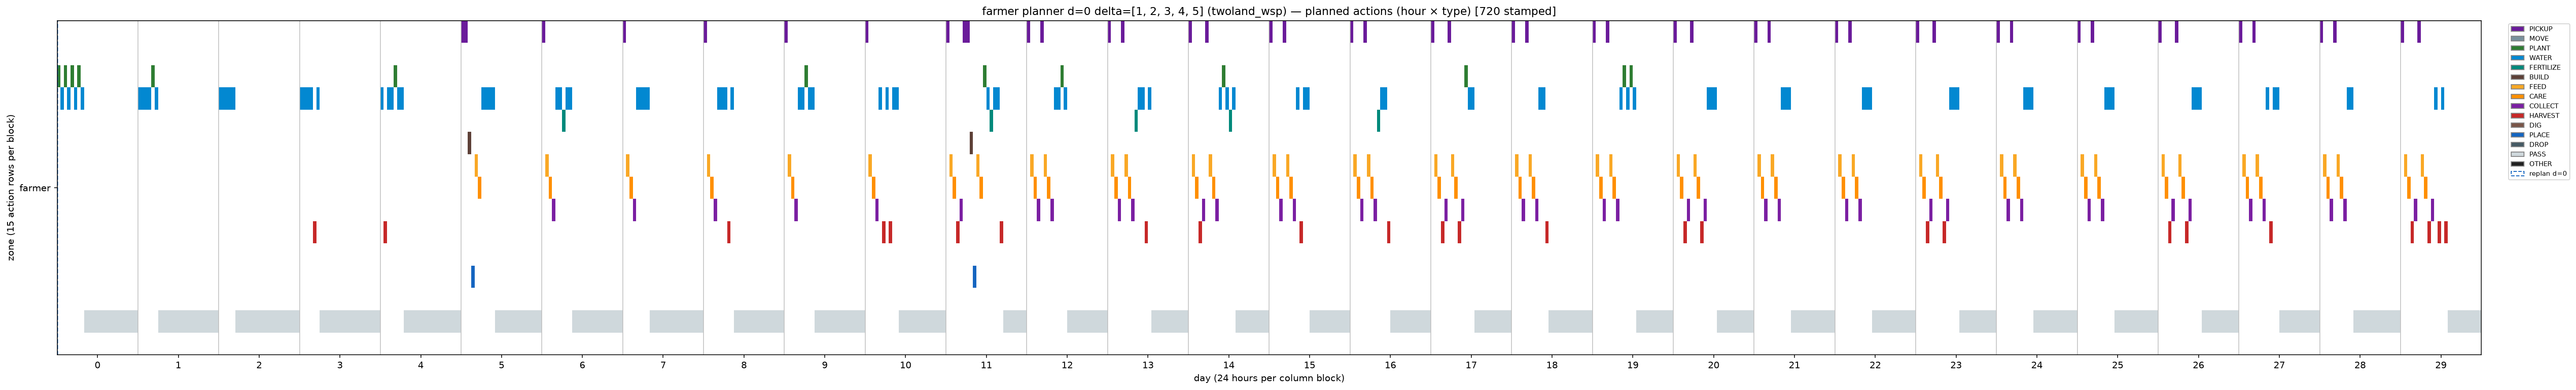

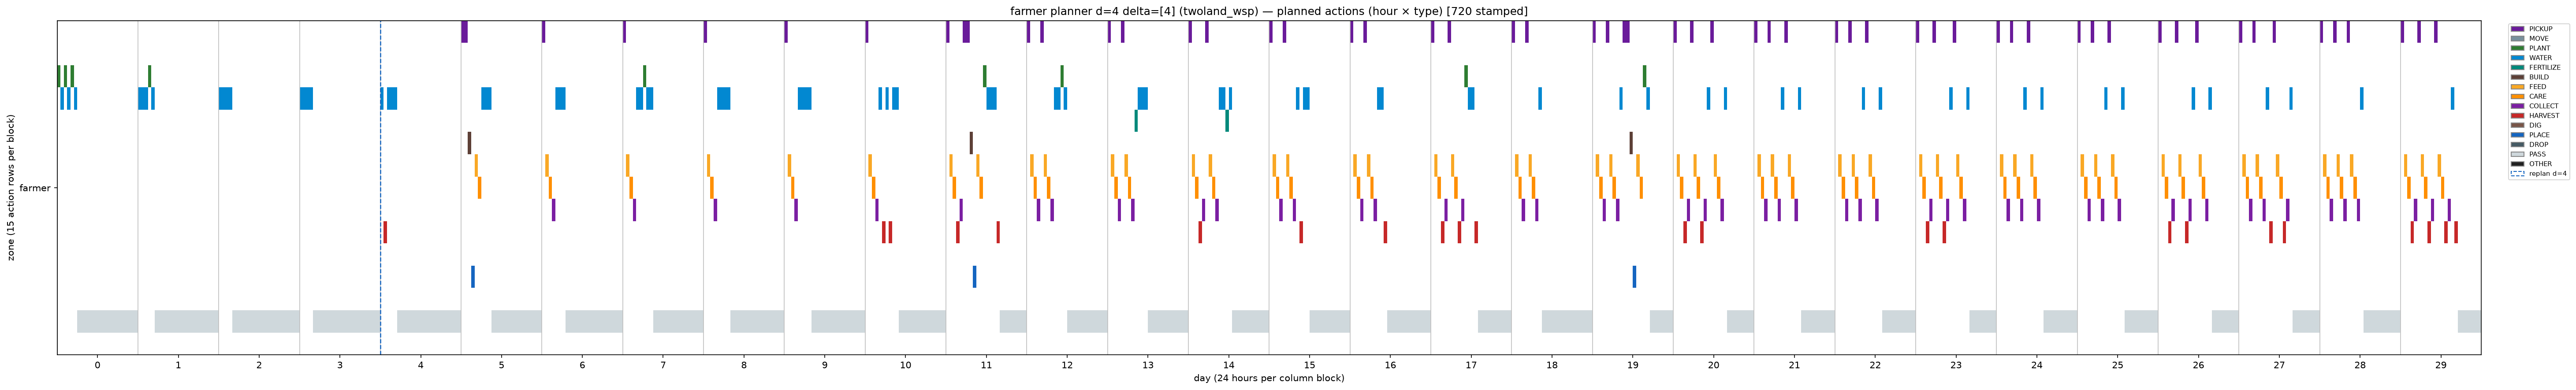

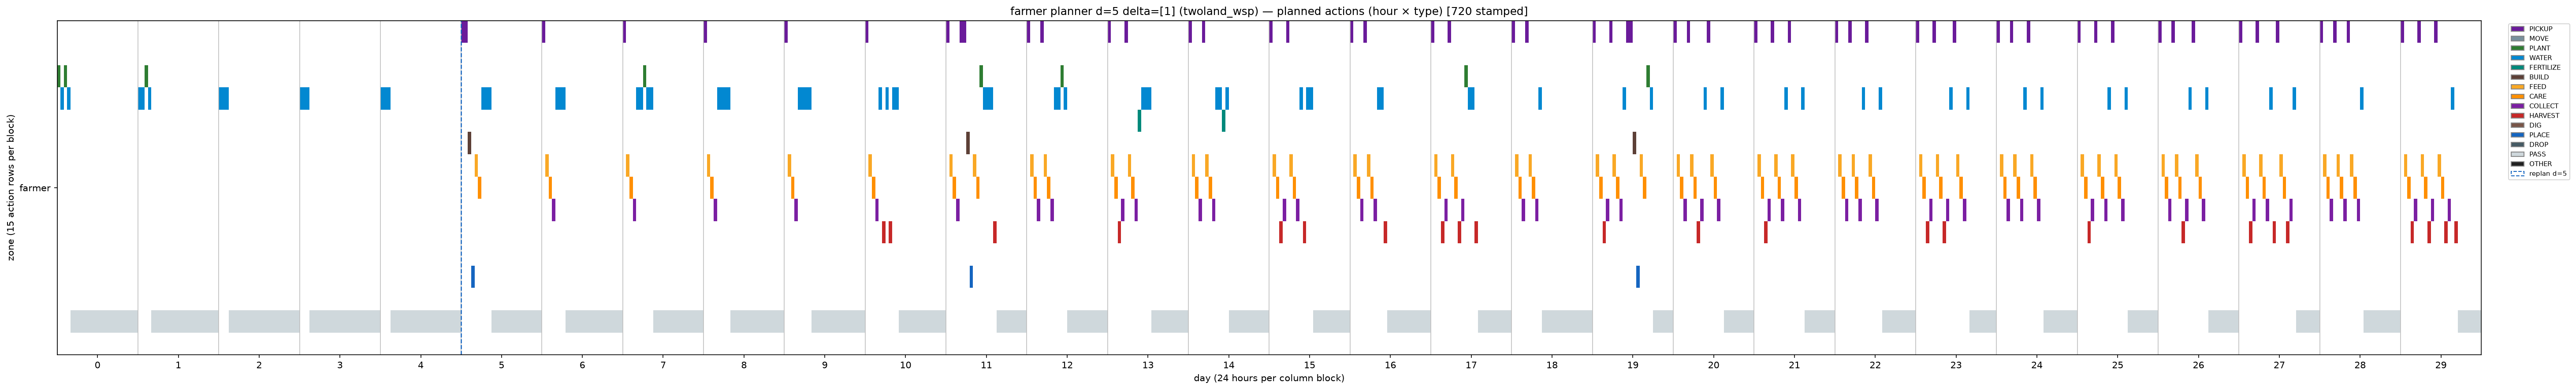

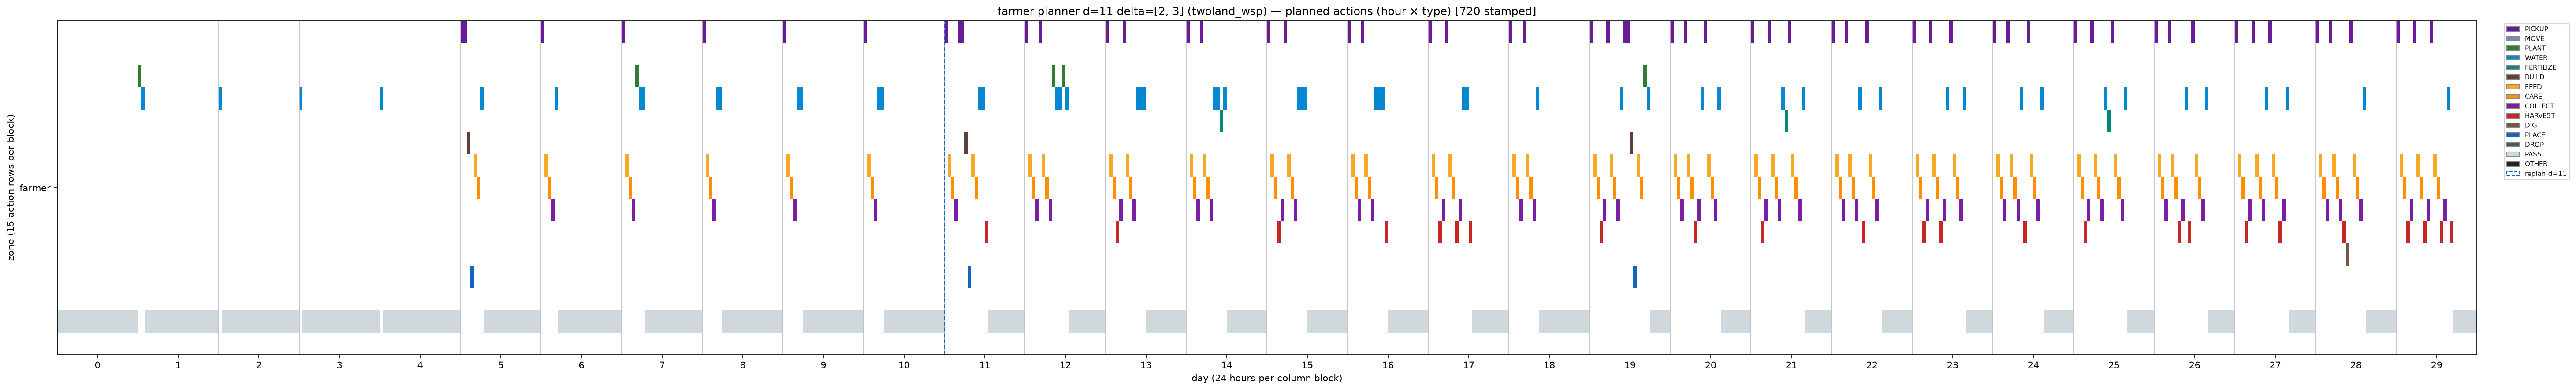

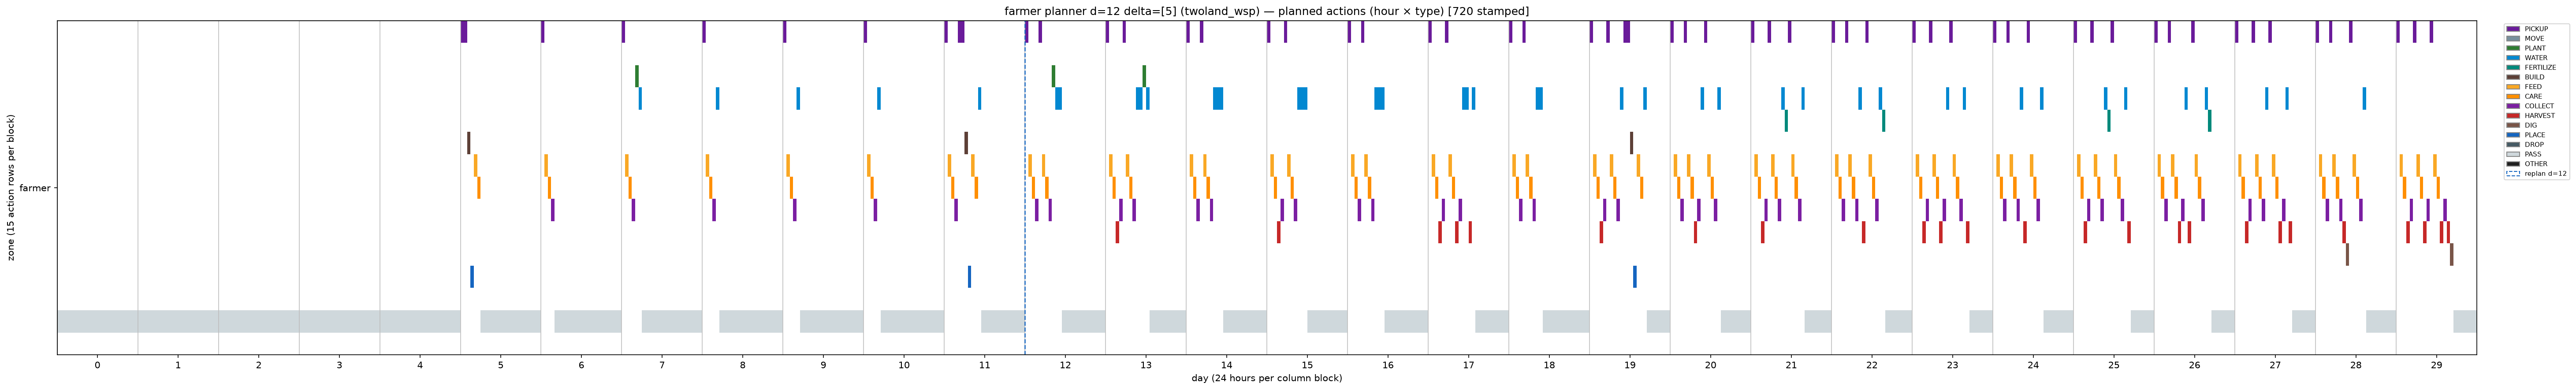

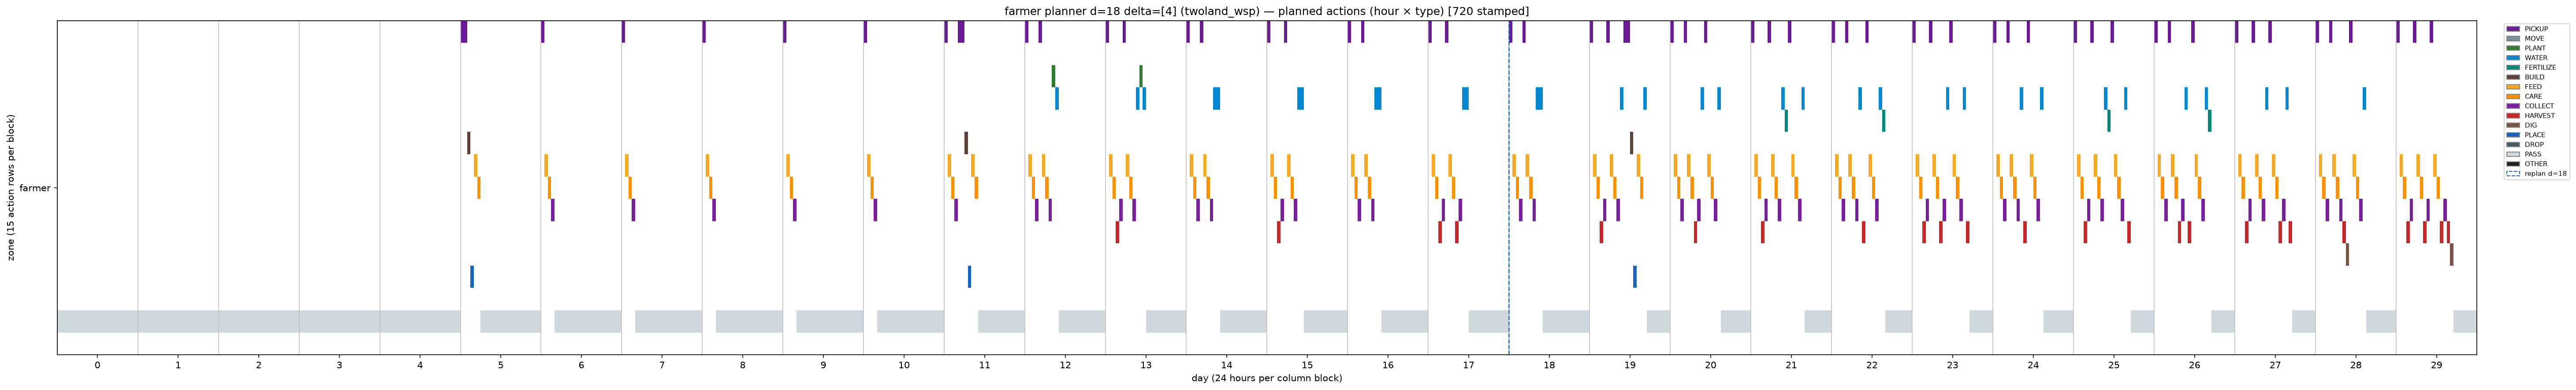

plotted 6/23 planned-action heatmaps


In [6]:
farmer_set = set(FARMER_TILES)
plans = load_wsp_plans(SMOKE_LOG) if SMOKE_LOG.exists() else []
board = empty_board()
plotted = 0
for plan in plans:
    delta = merge_wsp_plan(board, plan, tiles=farmer_set)
    if not delta:
        continue
    plotted += 1
    plot_planner_board_actions(
        board_for_plot(board),
        replan_day=plan.day,
        title=f"farmer planner d={plan.day} delta={sorted(t+1 for t in delta)} ({plan.solver})",
    )
print(f"plotted {plotted}/{len(plans)} planned-action heatmaps")
